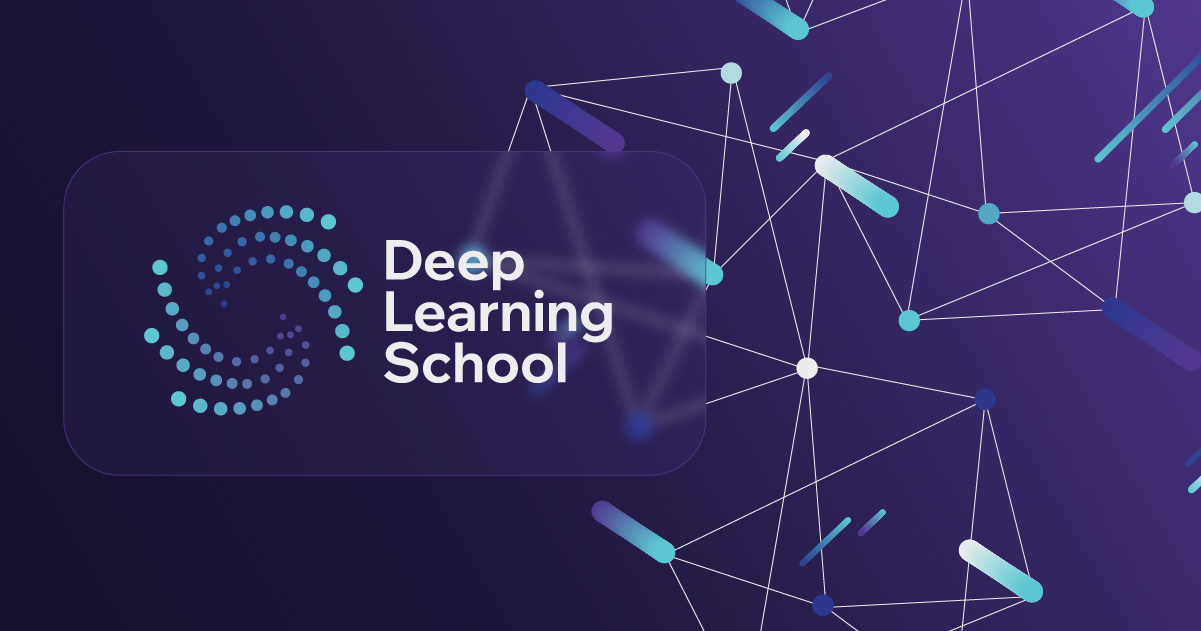

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

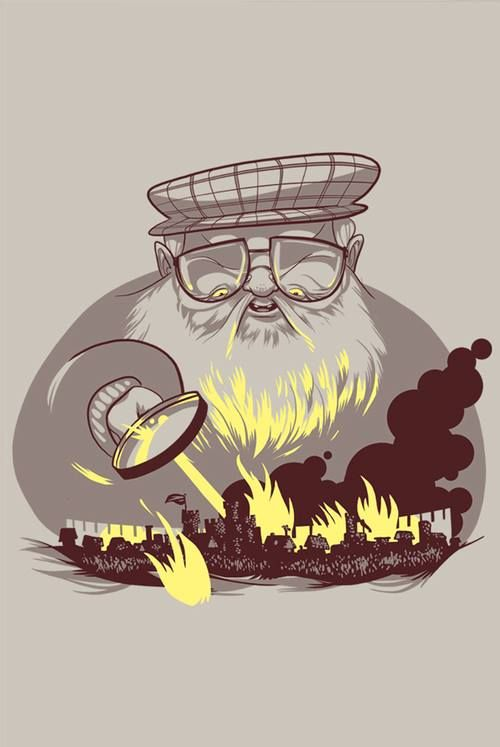

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 53.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 16.3MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [6]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No', encoding='utf-8')

Посмотрите, какие типы данных представлены в нашем датасете

In [7]:
print(data.dtypes)

name                 object
title                object
male                  int64
culture              object
dateOfBirth         float64
mother               object
father               object
heir                 object
house                object
spouse               object
book1                 int64
book2                 int64
book3                 int64
book4                 int64
book5                 int64
isAliveMother       float64
isAliveFather       float64
isAliveHeir         float64
isAliveSpouse       float64
isMarried             int64
isNoble               int64
age                 float64
numDeadRelations      int64
popularity          float64
isAlive               int64
dtype: object


Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [9]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [11]:
data.describe(include='number').T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [12]:
data.isnull().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [13]:
missing_pct = (data.isnull().sum() / len(data) * 100).round(1)

cols_high = missing_pct[missing_pct > 60].index.tolist()
cols_medium = missing_pct[(missing_pct >= 20) & (missing_pct <= 60)].index.tolist()
cols_low = missing_pct[missing_pct < 20].index.tolist()

print(f">60%: {len(cols_high)} столбцов — {cols_high}")
print(f"20-60%: {len(cols_medium)} столбцов — {cols_medium}")
print(f"<20%: {len(cols_low)} столбцов — {cols_low}")

>60%: 11 столбцов — ['culture', 'dateOfBirth', 'mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'age']
20-60%: 2 столбцов — ['title', 'house']
<20%: 12 столбцов — ['name', 'male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'popularity', 'isAlive']


**Анализ:** Самая проблемная группа — 11 столбцов с пропусками более 60%. Сюда входят все признаки, связанные с родственниками (отец, мать, супруг, наследник и их статус), а также dateOfBirth, age и culture. Некоторые признаки (например возраст) могут сильно влиять на выживаемость персонажа.
Два столбца — title и house — имеют средний уровень пропусков (20–60%).
Оставшиеся 12 столбцов не содержат пропусков вообще. Это надёжные данные.

В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

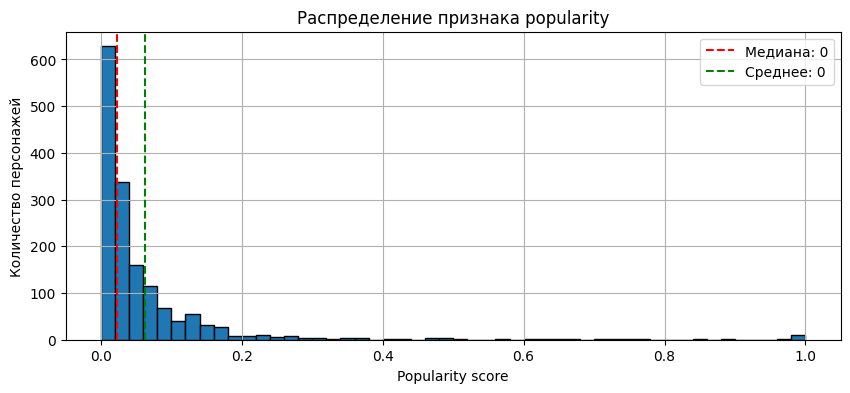

In [15]:
data['popularity'].hist(bins=50, figsize=(10, 4), edgecolor='black')
plt.xlabel('Popularity score')
plt.ylabel('Количество персонажей')
plt.title('Распределение признака popularity')

plt.axvline(data['popularity'].median(), color='red', linestyle='--', label=f'Медиана: {data["popularity"].median():.0f}')
plt.axvline(data['popularity'].mean(), color='green', linestyle='--', label=f'Среднее: {data["popularity"].mean():.0f}')
plt.legend()
plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


In [19]:
data['popularity_log'] = np.log10(data['popularity'] * 500 + 1)

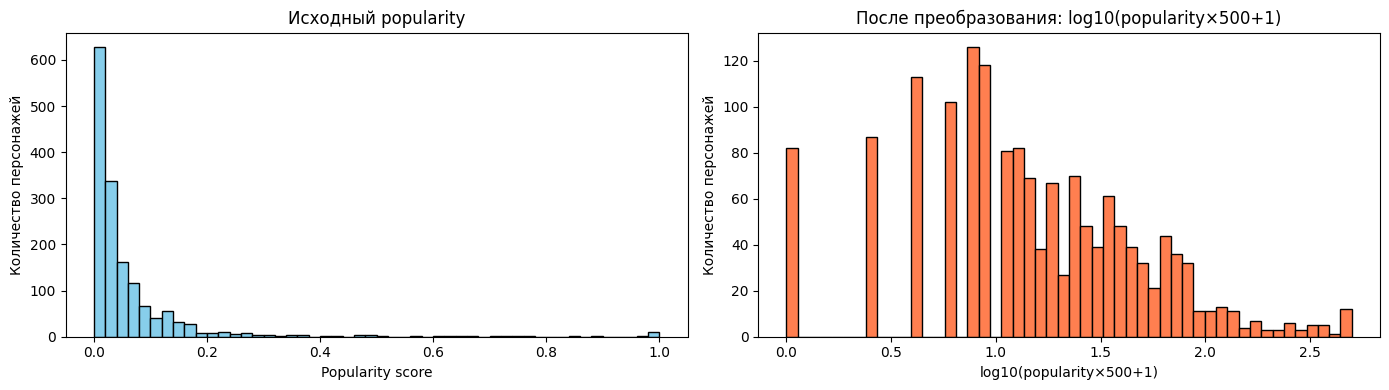

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Исходное распределение
axes[0].hist(data['popularity'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Исходный popularity')
axes[0].set_xlabel('Popularity score')
axes[0].set_ylabel('Количество персонажей')

# После логарифмирования
axes[1].hist(data['popularity_log'], bins=50, edgecolor='black', color='coral')
axes[1].set_title(f'После преобразования: log10(popularity×500+1)')
axes[1].set_xlabel('log10(popularity×500+1)')
axes[1].set_ylabel('Количество персонажей')

plt.tight_layout()
plt.show()

**Анализ**: распределение стало более симметричным

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64


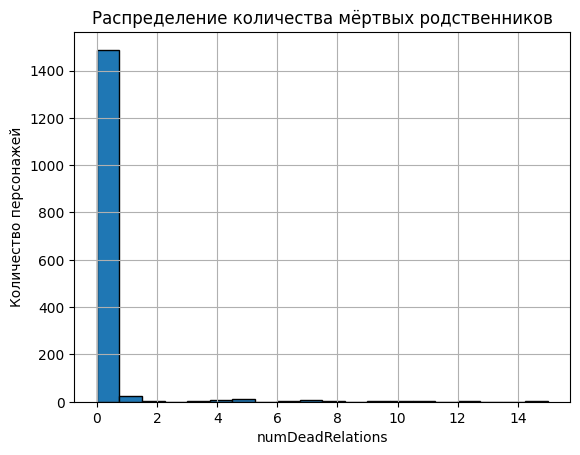


Новый признак boolDeadRelations:
boolDeadRelations
0    1488
1      69
Name: count, dtype: int64


In [21]:
print(data['numDeadRelations'].value_counts().sort_index())

data['numDeadRelations'].hist(bins=20, edgecolor='black')
plt.xlabel('numDeadRelations')
plt.ylabel('Количество персонажей')
plt.title('Распределение количества мёртвых родственников')
plt.show()

data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

print("\nНовый признак boolDeadRelations:")
print(data['boolDeadRelations'].value_counts())

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [22]:
data['age_value'] = data['age'].fillna(0)

data['age_no_data'] = data['age'].isnull().astype(int)

print("Исходный age (первые 10):")
print(data['age'].head(10))
print("\nНовые признаки (первые 10):")
print(data[['age', 'age_value', 'age_no_data']].head(10))
print("\nРаспределение age_no_data:")
print(data['age_no_data'].value_counts())

Исходный age (первые 10):
S.No
1      NaN
2     97.0
3      NaN
4     23.0
5     29.0
6      NaN
7     26.0
8      NaN
9      NaN
10     NaN
Name: age, dtype: float64

Новые признаки (первые 10):
       age  age_value  age_no_data
S.No                              
1      NaN        0.0            1
2     97.0       97.0            0
3      NaN        0.0            1
4     23.0       23.0            0
5     29.0       29.0            0
6      NaN        0.0            1
7     26.0       26.0            0
8      NaN        0.0            1
9      NaN        0.0            1
10     NaN        0.0            1

Распределение age_no_data:
age_no_data
1    1278
0     279
Name: count, dtype: int64


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

In [23]:
# Проверяем корреляцию между пропусками
print(data['age'].isnull().corr(data['dateOfBirth'].isnull()))

1.0


**Анализ**: созданные признаки полностью совпадают

In [30]:
data['dateOfBirth_value'] = data['dateOfBirth'].fillna(0)
dateOfBirth_no_data = data['dateOfBirth'].isnull().astype(int)

del dateOfBirth_no_data

data.drop('dateOfBirth_value', axis=1, inplace=True)

data.drop('dateOfBirth', axis=1, inplace=True)

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [31]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


**Анализ**: Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [34]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [35]:
cultures_inverted = {}
for group in cultures_grouped.keys():
    for culture in cultures_grouped[group]:
        cultures_inverted[culture] = group

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [37]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_inverted)


Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [38]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

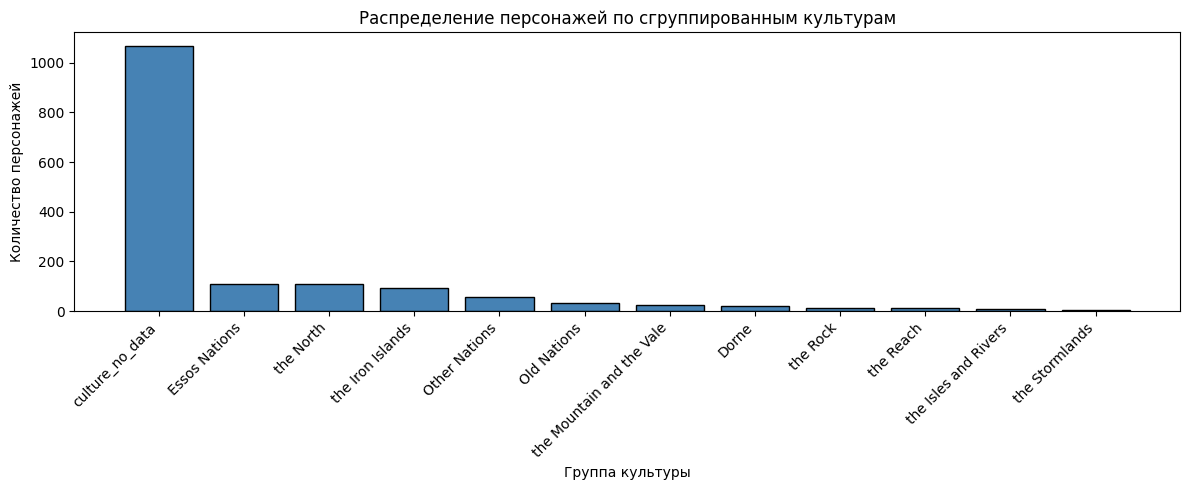

Статистика по группам:
Всего групп: 12
Среднее количество: 130
Медиана: 28
Минимум: 4 (the Stormlands)
Максимум: 1069 (culture_no_data)
Слабо представленные группы:
culture_grouped
Old Nations                  32
the Mountain and the Vale    25
Dorne                        21
the Rock                     14
the Reach                    13
the Isles and Rivers         10
the Stormlands                4
Name: count, dtype: int64


In [39]:
culture_counts = data['culture_grouped'].value_counts()

plt.figure(figsize=(12, 5))
bars = plt.bar(culture_counts.index, culture_counts.values, edgecolor='black', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Группа культуры')
plt.ylabel('Количество персонажей')
plt.title('Распределение персонажей по сгруппированным культурам')
plt.tight_layout()
plt.show()

print("Статистика по группам:")
print(f"Всего групп: {len(culture_counts)}")
print(f"Среднее количество: {culture_counts.mean():.0f}")
print(f"Медиана: {culture_counts.median():.0f}")
print(f"Минимум: {culture_counts.min()} ({culture_counts.idxmin()})")
print(f"Максимум: {culture_counts.max()} ({culture_counts.idxmax()})")

# Выделяем слабо представленные группы (< 5% от максимума)
threshold = culture_counts.max() * 0.05
weak_groups = culture_counts[culture_counts < threshold]
print(f"Слабо представленные группы:")
print(weak_groups)

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Анализ**: Много малопредставленных групп. Оставим только группы где >= 50 примеров, остальные объединим в Other_cultures

In [59]:
counts = data['culture_grouped'].value_counts()

threshold = 50
main_groups = counts[counts >= threshold].index.tolist()

data['culture_grouped'] = data['culture_grouped'].apply(
    lambda x: x if x in main_groups else 'Other_Cultures'
)

print("После объединения редких групп:")
print(data['culture_grouped'].value_counts())
print(f"\nУникальных категорий: {data['culture_grouped'].nunique()}")

После объединения редких групп:
culture_grouped
culture_no_data     1069
Other_Cultures       119
Essos Nations        109
the North            108
the Iron Islands      95
Other Nations         57
Name: count, dtype: int64

Уникальных категорий: 6


**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [60]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
mother,16
father,19
heir,20
house,315
spouse,186
book1,2


In [61]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
data.describe(include = 'number').T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2
isAliveSpouse,200.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

In [62]:
# 1. Находим все бинарные признаки (ровно 2 уникальных значения)
binary_cols = [col for col in data.columns if data[col].nunique() == 2]

# 2. Проверяем, есть ли в них пропуски
binary_with_nan = {}
for col in binary_cols:
    nan_count = data[col].isnull().sum()
    if nan_count > 0:
        binary_with_nan[col] = nan_count

# 3. Выводим результат
print("🔍 Бинарные признаки с пропусками:")
if binary_with_nan:
    for col, count in binary_with_nan.items():
        percent = count / len(data) * 100
        print(f"  • {col}: {count} пропусков ({percent:.1f}%)")

# 4. Для наглядности: таблица со всеми бинарными признаками
print("Все бинарные признаки:")
binary_stats = pd.DataFrame({
    'Признак': binary_cols,
    'Уникальные значения': [data[col].unique() for col in binary_cols],
    'Пропуски': [data[col].isnull().sum() for col in binary_cols]
})
print(binary_stats.to_string(index=False))

🔍 Бинарные признаки с пропусками:
  • isAliveMother: 1539 пропусков (98.8%)
  • isAliveFather: 1535 пропусков (98.6%)
  • isAliveHeir: 1536 пропусков (98.7%)
  • isAliveSpouse: 1357 пропусков (87.2%)
Все бинарные признаки:
          Признак Уникальные значения  Пропуски
             male              [1, 0]         0
            book1              [0, 1]         0
            book2              [0, 1]         0
            book3              [0, 1]         0
            book4              [0, 1]         0
            book5              [0, 1]         0
    isAliveMother     [1.0, nan, 0.0]      1539
    isAliveFather     [0.0, nan, 1.0]      1535
      isAliveHeir     [0.0, nan, 1.0]      1536
    isAliveSpouse     [nan, 1.0, 0.0]      1357
        isMarried              [0, 1]         0
          isNoble              [0, 1]         0
          isAlive              [0, 1]         0
boolDeadRelations              [1, 0]         0
      age_no_data              [1, 0]         0


Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [63]:
# Анализ связи признака с целевой переменной isAlive

print("Среднее значение isAlive по категориям isAliveSpouse:")
print(data.groupby('isAliveSpouse', dropna=False)['isAlive'].mean())
print()


Среднее значение isAlive по категориям isAliveSpouse:
isAliveSpouse
0.0    0.619048
1.0    0.753165
NaN    0.786293
Name: isAlive, dtype: float64



🔗 Корреляция бинарных признаков с isAlive:
book4                0.284
boolDeadRelations    0.178
male                 0.148
age_no_data          0.114
book1                0.112
isNoble              0.061
book2                0.056
isMarried            0.049
book5                0.033
book3                0.018
Name: isAlive, dtype: float64


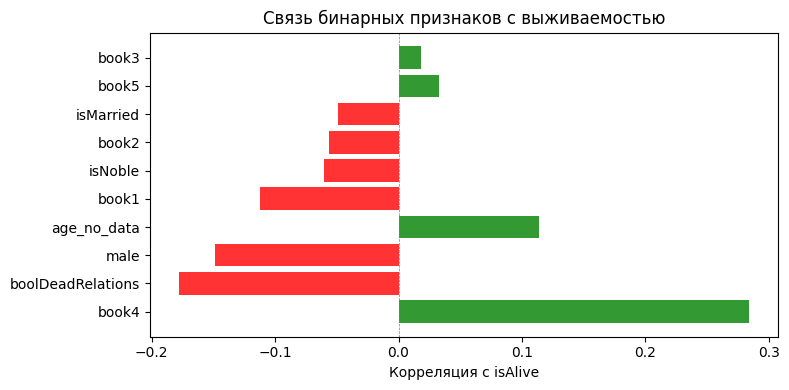

In [64]:
# 1. Выбираем бинарные признаки БЕЗ пропусков (исключая целевую переменную)
clean_binary_cols = [col for col in binary_cols
                     if col != 'isAlive' and data[col].isnull().sum() == 0]

# 2. Считаем корреляцию Пирсона с isAlive
correlations = data[clean_binary_cols + ['isAlive']].corr()['isAlive'].drop('isAlive')

# 3. Сортируем по абсолютному значению и выводим
print("🔗 Корреляция бинарных признаков с isAlive:")
print(correlations.abs().sort_values(ascending=False).round(3))

# 4. Визуализация (опционально)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
corr_sorted = correlations.sort_values(key=abs, ascending=False)
colors = ['green' if c > 0 else 'red' for c in corr_sorted.values]
plt.barh(corr_sorted.index, corr_sorted.values, color=colors, alpha=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('Корреляция с isAlive')
plt.title('Связь бинарных признаков с выживаемостью')
plt.tight_layout()
plt.show()

In [65]:
data_model = data.copy()

In [66]:
data = data_model.copy()

# Удаляем признаки со слабой корреляцией (< 0.1)
del data['isNoble']
del data['book2']
del data['isMarried']
del data['book5']
del data['book3']


print(f"Оставшиеся признаки: {data.columns.tolist()}")
print(f"Размер датасета: {data.shape}")

Оставшиеся признаки: ['name', 'title', 'male', 'culture', 'mother', 'father', 'heir', 'house', 'spouse', 'book1', 'book4', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'age', 'numDeadRelations', 'popularity', 'isAlive', 'popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'culture_grouped']
Размер датасета: (1557, 24)


In [77]:
print(data_model)

                      name                 title  male     culture  \
S.No                                                                 
1     Viserys II Targaryen                   NaN     1         NaN   
2              Walder Frey  Lord of the Crossing     1    Rivermen   
3             Addison Hill                   Ser     1         NaN   
4              Aemma Arryn                 Queen     0         NaN   
5           Sylva Santagar            Greenstone     0     Dornish   
...                    ...                   ...   ...         ...   
1553                Marwyn           Archmaester     1         NaN   
1554          Masha Heddle                   NaN     0         NaN   
1555      Matthos Seaworth                   NaN     1         NaN   
1556            Meera Reed                   NaN     0  Crannogmen   
1557    Melara Hetherspoon                   NaN     0         NaN   

                  mother            father                heir  \
S.No                   

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [123]:
# 1. Копия из резерва
data = data_model.copy()

# 2. Удаляем идентификаторы
data.drop(columns=['name'], inplace=True, errors='ignore')

# 3. Находим категориальные признаки с малым числом уникальных значений
categorical_cols = [col for col in data.columns
                    if data[col].dtype == 'object'
                    and col != 'isAlive'
                    and data[col].nunique() < 20]

print(f"Будут закодированы: {categorical_cols}")

# 4. Кодируем ТОЛЬКО эти признаки
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# 5. Конвертируем все столбцы в числовой тип
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0).astype(int)
bool_cols = data.select_dtypes(include=['bool']).columns.tolist()

if bool_cols:
    data[bool_cols] = data[bool_cols].astype(int)
    print(f"✅ Конвертировано {len(bool_cols)} столбцов из bool в int")

# Финальная проверка
print(f"Нечисловых столбцов: {len(data.select_dtypes(exclude=['number']).columns)}")
print(f"📊 Размер датасета: {data.shape}")
print(f"📋 Типы данных:\n{data.dtypes.value_counts()}")

Будут закодированы: ['mother', 'father', 'culture_grouped']
✅ Конвертировано 38 столбцов из bool в int
Нечисловых столбцов: 0
📊 Размер датасета: (1557, 63)
📋 Типы данных:
int64      55
float64     8
Name: count, dtype: int64


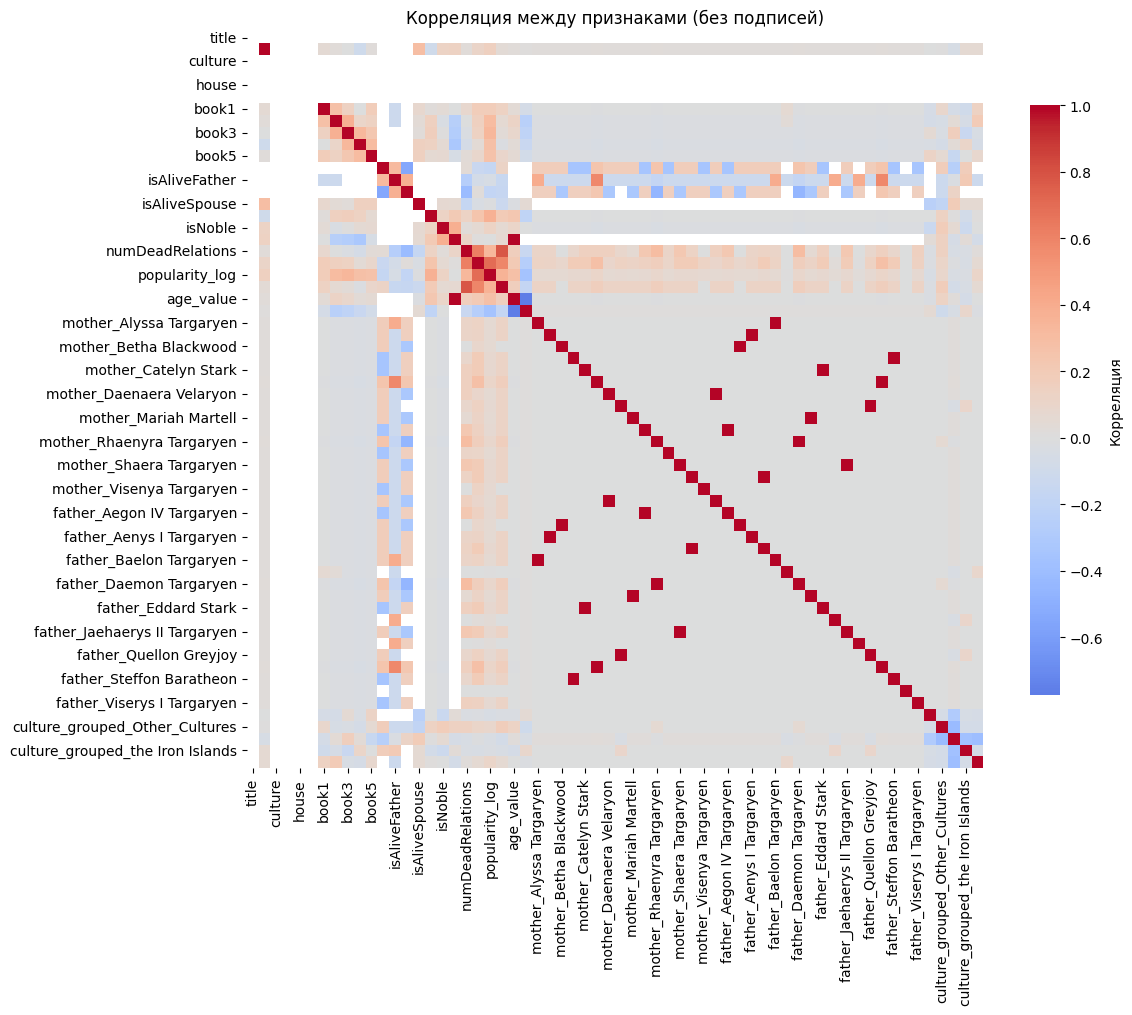

In [124]:
# Анализ корреляции между количественными признаками

# Выделяем числовые признаки (исключая целевую переменную)
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'isAlive']

# Корреляционная матрица
corr_matrix = data[numeric_cols].corr()

# Визуализация (ЧИСТАЯ, без подписей)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Корреляция'})
plt.title('Корреляция между признаками (без подписей)')
plt.tight_layout()
plt.show()

**Анализ**: Присутствуют признаки с корреляцией 1. Удалим признаки с сильной корреляцией

In [125]:
# Удаление признаков с сильной корреляцией (> 0.7)

corr_matrix = data[numeric_cols].corr()
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            # Оставляем признак, который сильнее коррелирует с isAlive
            c1 = abs(data[corr_matrix.columns[i]].corr(data['isAlive']))
            c2 = abs(data[corr_matrix.columns[j]].corr(data['isAlive']))
            to_drop.add(corr_matrix.columns[i] if c1 < c2 else corr_matrix.columns[j])

# Удаляем признаки
if to_drop:
    data.drop(columns=list(to_drop), inplace=True)
    print(f"Удалено признаков: {len(to_drop)}")

# Обновляем список признаков
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'isAlive']
print(f"Осталось признаков: {len(numeric_cols)}")

Удалено признаков: 16
Осталось признаков: 46


In [126]:
data_model3=data.copy()

In [127]:
data=data_model3.copy()
isalive_cols = [col for col in data.columns if col.startswith('isAlive') and col != 'isAlive']

print("Признаки типа 'isAlive*':")
for col in isalive_cols:
    nan_pct = data[col].isnull().mean() * 100
    print(f"  • {col}: {nan_pct:.1f}% пропусков")

Признаки типа 'isAlive*':
  • isAliveMother: 98.8% пропусков
  • isAliveFather: 98.6% пропусков
  • isAliveHeir: 98.7% пропусков
  • isAliveSpouse: 87.2% пропусков


In [128]:
if 'age' in data.columns:
    data.drop(columns=['age'], inplace=True)

In [129]:
# Создаём обобщённый признак из isAlive* колонок

alive_cols = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
available = [col for col in alive_cols if col in data.columns]

if available:
    data['has_alive_relative'] = data[available].max(axis=1, skipna=True).fillna(0).astype(int)


    # Удаляем исходные колонки с пропусками
    data.drop(columns=available, inplace=True)
    print(f"Создан 'has_alive_relative', удалено: {available}")

Создан 'has_alive_relative', удалено: ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

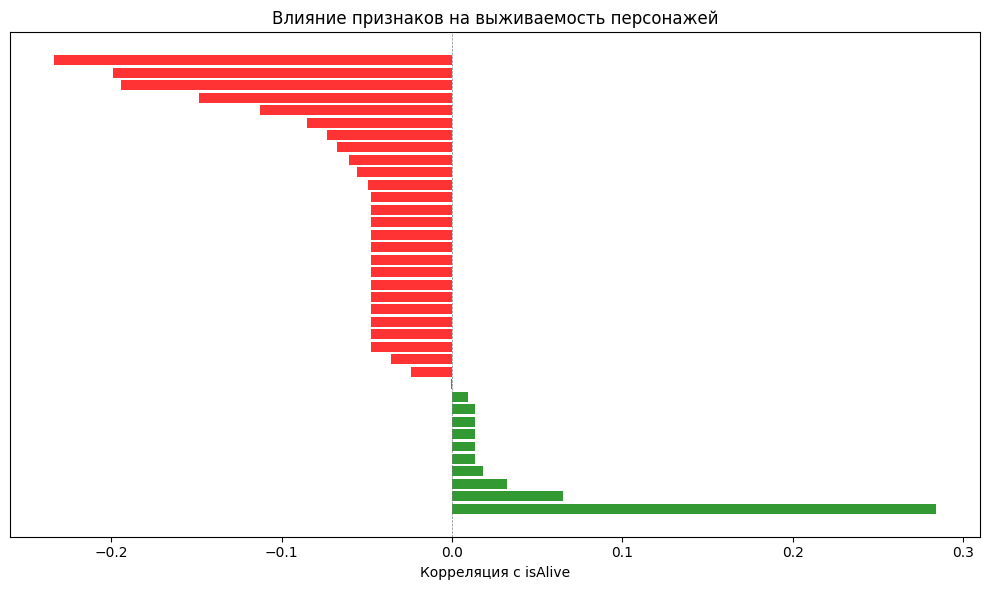

Топ-10 признаков по влиянию на isAlive:
book4                               0.284
culture_grouped_the Iron Islands    0.065
book5                               0.033
book3                               0.018
father_Qhorwyn Hoare                0.014
father_Tristifer IV Mudd            0.014
mother_Cassana Estermont            0.014
mother_Lady of House Sunderly       0.014
father_Brandon Stark                0.014
culture_grouped_culture_no_data     0.010
Name: isAlive, dtype: float64
   • |corr| ≥ 0.15: 4 признаков
   • |corr| ≥ 0.1: 6 признаков
   • |corr| ≥ 0.05: 12 признаков


In [130]:
# Анализ влияния признаков на целевую переменную isAlive

# 1. Корреляция всех признаков с isAlive
corr_with_target = data.corr()['isAlive'].drop('isAlive').sort_values(ascending=False)

# 2. Визуализация (без подписей слева для чистоты)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('Корреляция с isAlive')
plt.title('Влияние признаков на выживаемость персонажей')
plt.yticks([])
plt.tight_layout()
plt.show()

# 3. Топ-10 самых важных признаков (текстовый вывод)
print("Топ-10 признаков по влиянию на isAlive:")
print(corr_with_target.abs().head(10).round(3))

# 4. Cколько признаков выше порога?
for thresh in [0.15, 0.1, 0.05]:
    count = (corr_with_target.abs() >= thresh).sum()
    print(f"   • |corr| ≥ {thresh}: {count} признаков")

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [131]:
threshold = 0.03

# Отбираем признаки
selected_features = corr_with_target[corr_with_target.abs() >= threshold].index.tolist()

# Создаём X и y
X = data[selected_features]
y = data['isAlive']

# Финальная проверка
print(f"Признаков: {X.shape[1]}")
print(f"Наблюдений: {X.shape[0]}")
print(f"Пропусков: {X.isnull().sum().sum()}")
print(f"Баланс классов: {y.mean():.2%} живых")
print(f"\n📋 Признаки: {selected_features}")


Признаков: 28
Наблюдений: 1557
Пропусков: 0
Баланс классов: 77.84% живых

📋 Признаки: ['book4', 'culture_grouped_the Iron Islands', 'book5', 'culture_grouped_Other Nations', 'mother_Catelyn Stark', 'mother_Mariah Martell', 'mother_Visenya Targaryen', 'mother_Valaena Velaryon', 'mother_Alyssa Velaryon', 'father_Viserys I Targaryen', 'mother_Shaera Targaryen', 'mother_Alyssa Targaryen', 'mother_Betha Blackwood', 'mother_Daenaera Velaryon', 'mother_Rhaenys Targaryen', 'father_Halleck Hoare', 'mother_Naerys Targaryen', 'isMarried', 'book2', 'isNoble', 'mother_Rhaenyra Targaryen', 'has_alive_relative', 'culture_grouped_Other_Cultures', 'book1', 'male', 'popularity', 'numDeadRelations', 'popularity_log']


**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [132]:
from sklearn.model_selection import train_test_split

In [133]:

# Разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Проверка результата

print(f" X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"\n📋 Баланс классов:")
print(f"   В train: {y_train.mean():.2%} живых ({y_train.sum()} из {len(y_train)})")
print(f"   В val:   {y_val.mean():.2%} живых ({y_val.sum()} из {len(y_val)})")
print(f"   В исходных: {y.mean():.2%} живых")

 X_train: (1245, 28), y_train: (1245,)
X_val: (312, 28), y_val: (312,)

📋 Баланс классов:
   В train: 77.83% живых (969 из 1245)
   В val:   77.88% живых (243 из 312)
   В исходных: 77.84% живых


## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [119]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Шаг 1: Создание модели
model = LogisticRegression(random_state=42, max_iter=1000)

# Шаг 2: Обучение модели
model.fit(X_train, y_train)




LogisticRegression(max_iter=1000, random_state=42)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [137]:
# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val)

# Шаг 4. Оценка предсказания по метрике accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7724


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

Меня устраивает полученный Accuracy и я решила оставить текущую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [139]:
data_test = pd.read_csv('game_of_thrones_test.csv')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [140]:
data_test.loc[data_test['age'] < 0]

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
127,1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
311,1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Восстанавливаем исходные обучающие данные
data_train = pd.read_csv('game_of_thrones_train.csv', index_col='S.No', encoding='utf-8')

# 2. Применяем те же преобразования к обучающим данным, что и раньше
# (копируем преобразования, которые делали ранее)

# 2.1 popularity_log
data_train['popularity_log'] = np.log10(data_train['popularity'] * 500 + 1)

# 2.2 boolDeadRelations
data_train['boolDeadRelations'] = (data_train['numDeadRelations'] > 0).astype(int)

# 2.3 Обработка возраста
data_train['age_value'] = data_train['age'].fillna(0)
data_train['age_no_data'] = data_train['age'].isnull().astype(int)

if 'age' in data_train.columns:
    data_train.drop(columns=['age'], inplace=True)

# 2.4 Удаляем dateOfBirth
if 'dateOfBirth' in data_train.columns:
    data_train.drop('dateOfBirth', axis=1, inplace=True)

# 2.5 Группировка культуры
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']
}

cultures_inverted = {}
for group in cultures_grouped.keys():
    for culture in cultures_grouped[group]:
        cultures_inverted[culture] = group

data_train['culture_grouped'] = data_train['culture'].str.lower().map(cultures_inverted)
data_train['culture_grouped'] = data_train['culture_grouped'].fillna('culture_no_data')

# 2.6 Определяем основные группы культур
train_culture_groups = data_train['culture_grouped'].value_counts()
main_groups = train_culture_groups[train_culture_groups >= 50].index.tolist()

data_train['culture_grouped'] = data_train['culture_grouped'].apply(
    lambda x: x if x in main_groups else 'Other_Cultures'
)

# 2.7 Создание has_alive_relative
alive_cols = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
available_cols = [col for col in alive_cols if col in data_train.columns]

if available_cols:
    data_train['has_alive_relative'] = data_train[available_cols].max(axis=1, skipna=True).fillna(0).astype(int)
    data_train.drop(columns=available_cols, inplace=True)
else:
    data_train['has_alive_relative'] = 0

# 2.8 Удаление ненужных столбцов
cols_to_drop = ['name', 'title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']
for col in cols_to_drop:
    if col in data_train.columns:
        data_train.drop(columns=[col], inplace=True)

# 2.9 Кодирование категориальных признаков
categorical_cols = [col for col in data_train.columns
                    if data_train[col].dtype == 'object'
                    and col != 'isAlive'
                    and data_train[col].nunique() < 20]

if categorical_cols:
    data_train = pd.get_dummies(data_train, columns=categorical_cols, drop_first=True)

# 2.10 Конвертируем bool в int
bool_cols = data_train.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    data_train[bool_cols] = data_train[bool_cols].astype(int)

# 2.11 Приводим к числовым типам
for col in data_train.columns:
    if data_train[col].dtype == 'object':
        data_train[col] = pd.to_numeric(data_train[col], errors='coerce').fillna(0).astype(int)

# 2.12 Заполняем пропуски
data_train = data_train.fillna(0)


# 3. Создаем X и y для обучения
# Целевая переменная
y = data_train['isAlive']

# Признаки (исключаем целевую переменную)
X = data_train.drop('isAlive', axis=1)

# 4. Разделяем на train и val
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")

# 5. Обучаем модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print(f"\nМодель обучена!")

# 6. Оцениваем на валидации
y_pred_val = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy на валидации: {accuracy:.4f}")

# 7. Загружаем и преобразуем тестовые данные
data_test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No', encoding='utf-8')

# Исправляем ошибки
data_test.loc[data_test.index == 1685, 'dateOfBirth'] = 278.0
data_test.loc[data_test.index == 1685, 'age'] = 0.0
data_test.loc[data_test.index == 1869, 'dateOfBirth'] = 299.0
data_test.loc[data_test.index == 1869, 'age'] = 0.0

# Применяем те же преобразования
data_test['popularity_log'] = np.log10(data_test['popularity'] * 500 + 1)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)
data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = data_test['age'].isnull().astype(int)

if 'age' in data_test.columns:
    data_test.drop(columns=['age'], inplace=True)
if 'dateOfBirth' in data_test.columns:
    data_test.drop('dateOfBirth', axis=1, inplace=True)

# Группировка культуры
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')
data_test['culture_grouped'] = data_test['culture_grouped'].apply(
    lambda x: x if x in main_groups else 'Other_Cultures'
)

# has_alive_relative
alive_cols = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
available_cols = [col for col in alive_cols if col in data_test.columns]

if available_cols:
    data_test['has_alive_relative'] = data_test[available_cols].max(axis=1, skipna=True).fillna(0).astype(int)
    data_test.drop(columns=available_cols, inplace=True)
else:
    data_test['has_alive_relative'] = 0

# Удаление ненужных столбцов
cols_to_drop = ['name', 'title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']
for col in cols_to_drop:
    if col in data_test.columns:
        data_test.drop(columns=[col], inplace=True)

# Кодирование категориальных признаков
categorical_cols = [col for col in data_test.columns
                    if data_test[col].dtype == 'object'
                    and col != 'isAlive'
                    and data_test[col].nunique() < 20]

if categorical_cols:
    data_test = pd.get_dummies(data_test, columns=categorical_cols, drop_first=True)

# Конвертируем bool в int
bool_cols = data_test.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    data_test[bool_cols] = data_test[bool_cols].astype(int)

# Приводим к числовым типам
for col in data_test.columns:
    if data_test[col].dtype == 'object':
        data_test[col] = pd.to_numeric(data_test[col], errors='coerce').fillna(0).astype(int)

# Добавляем недостающие столбцы
for col in X_train.columns:
    if col not in data_test.columns:
        data_test[col] = 0

# Оставляем только нужные столбцы
data_test = data_test[X_train.columns]

# Заполняем пропуски
data_test = data_test.fillna(0)


   X_train: (1245, 20), y_train: (1245,)
   X_val: (312, 20), y_val: (312,)

Модель обучена!
Accuracy на валидации: 0.7949


### Файл `submission.csv`

In [143]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 9.19MB/s]


In [159]:
# Делаем предсказания
y_pred_test = model.predict(data_test)

In [160]:
# Создаём файл для сабмишна
submission = pd.read_csv("/content/submission.csv")

In [157]:
submission

,S.No,isAlive
0,1558,0
1,1559,1
2,1560,1
3,1561,1
4,1562,1
...,...,...
384,1942,0
385,1943,1
386,1944,1
387,1945,1


Сохранить измененный Pandas DataFrame в csv файл:

In [158]:
# Заменяем предсказания
submission['isAlive'] = y_pred_test
submission.to_csv("/content/new_submission.csv", index=False)